### Purpose of this notebook would be to do various systematic studies on data [CREATED 02/24/2023]

Notes:
1. Hist histogram bins start from 0 but ROOT histogram bins start from 1

In [1]:
import hist
import json
import uproot
import numpy as np
import pandas as pd
from hist import Hist
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Reading the ROOT file
file = uproot.open('../pdout/qelas_ana_data_sbs4_sbs50p_model2_pass1.root')
file.classnames()

{'Tout;10': 'TTree',
 'c1;1': 'TCanvas',
 'c2;1': 'TCanvas',
 'h_W;1': 'TH1F',
 'h_W_cut;1': 'TH1F',
 'h_W_acut;1': 'TH1F',
 'h_dpel;1': 'TH1D',
 'h_Q2;1': 'TH1F',
 'h_dxHCAL;1': 'TH1F',
 'h_dyHCAL;1': 'TH1F',
 'h2_rcHCAL;1': 'TH2F',
 'h2_dxdyHCAL;1': 'TH2F',
 'h2_xyHCAL_p;1': 'TH2F',
 'h2_xyHCAL_n;1': 'TH2F',
 'h_coin_time;1': 'TH1F'}

In [3]:
# Accessing the tree and reading it as pandas df
tree = file['Tout']
tdf = tree.arrays(library="pd")
tdf.columns
#tdf.head()

Index(['WCut', 'pCut', 'nCut', 'fiduCut', 'rnum', 'ebeam', 'ebeam_std',
       'gevnum', 'nu', 'Q2', 'W2', 'W', 'dpel', 'ephi', 'etheta', 'pcentral',
       'thetapq_p', 'thetapq_n', 'vz', 'trP', 'trX', 'trY', 'trTh', 'trPh',
       'tgX', 'tgY', 'tgTh', 'tgPh', 'ePS', 'rblkPS', 'cblkPS', 'idblkPS',
       'atimePS', 'eSH', 'xSH', 'ySH', 'rblkSH', 'cblkSH', 'idblkSH',
       'atimeSH', 'eHCAL', 'xHCAL', 'yHCAL', 'idblkHCAL', 'rblkHCAL',
       'cblkHCAL', 'atimeHCAL', 'tdcHCAL', 'xHCAL_exp', 'yHCAL_exp', 'dx',
       'dy', 'ToF_n', 'ncltmeanHODO', 'cltmeanHODO', 'bbT_trig', 'coinT_trig'],
      dtype='object')

In [4]:
# Defining cut variables from tree to make my life easier
WCut = tdf['WCut']
fCut = tdf['fiduCut']
pCut = tdf['pCut']
nCut = tdf['nCut']

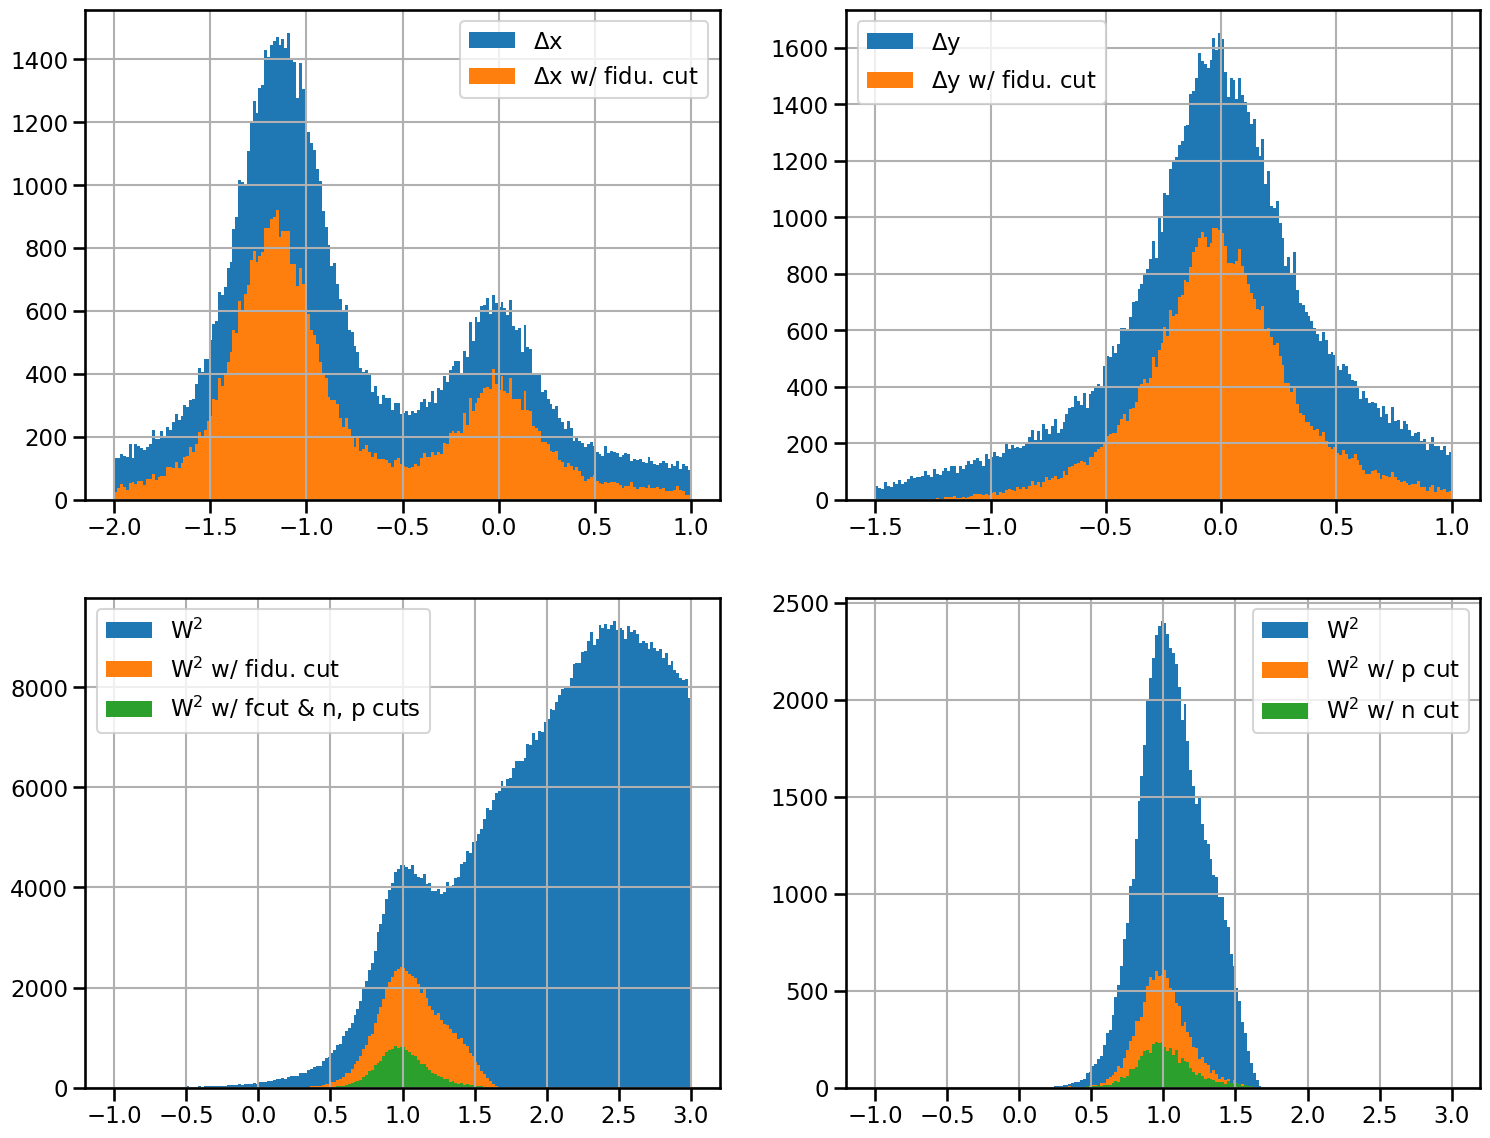

In [5]:
# Lets look at a few important histograms first
plt.style.use('default')
sns.set_context('talk')
fig, ax = plt.subplots(2, 2)
fig.set_size_inches(18, 14)
tdf['dx'][WCut].hist(bins=200, range=(-2, 1), ax=ax[0, 0], label=r'$\Delta$x')
tdf['dx'][WCut & fCut].hist(bins=200, range=(-2, 1), ax=ax[0, 0], label=r'$\Delta$x w/ fidu. cut')
tdf['dy'][WCut].hist(bins=200, range=(-1.5, 1), ax=ax[0, 1], label=r'$\Delta$y')
tdf['dy'][WCut & fCut].hist(bins=200, range=(-1.5, 1), ax=ax[0, 1], label=r'$\Delta$y w/ fidu. cut')
tdf['W2'].hist(bins=200, range=(-1, 3), ax=ax[1, 0], label=r'W$^2$')
tdf['W2'][fCut].hist(bins=200, range=(-1, 3), ax=ax[1, 0], label=r'W$^2$ w/ fidu. cut')
tdf['W2'][fCut & (nCut | pCut)].hist(bins=200, range=(-1, 3), ax=ax[1, 0], label='W$^2$ w/ fcut & n, p cuts')
tdf['W2'][fCut].hist(bins=200, range=(-1, 3), ax=ax[1, 1], label=r'W$^2$')
tdf['W2'][fCut & pCut].hist(bins=200, range=(-1, 3), ax=ax[1, 1], label=r'W$^2$ w/ p cut')
tdf['W2'][fCut & nCut].hist(bins=200, range=(-1, 3), ax=ax[1, 1], label=r'W$^2$ w/ n cut')
#tdf['ToF_n'][WCut].hist(bins=80, range=(38, 42), ax=ax[1, 1], label='ToF (ns), no deflection')
for i in range(2):
    for j in range(2):
        ax[i, j].legend()

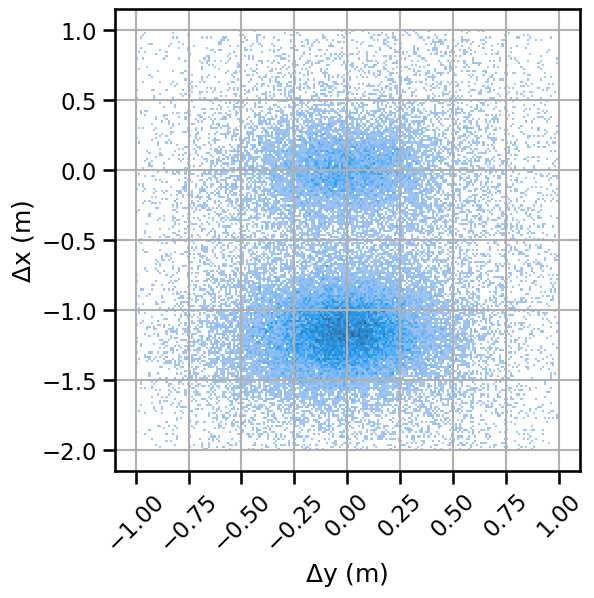

In [6]:
fig, ax = plt.subplots()
fig.set_size_inches(6, 6)
sns.set_style('whitegrid')
sns.set_context('notebook')
#ax.hist2d(tdf['dy'][WCut & fCut], tdf['dx'][WCut & fCut], bins=(200, 200), range=[[-1, 1], [-2, 1]])
sns.histplot(tdf[WCut & fCut], x='dy', y='dx', bins=(200, 200), binrange=((-1, 1), (-2, 1)), ax=ax)
ax.set_xlabel(r'$\Delta$y (m)')
ax.tick_params(axis='x', labelrotation = 45)
#plt.xticks(rotation=45)
ax.set_ylabel(r'$\Delta$x (m)')
plt.grid()
plt.show()

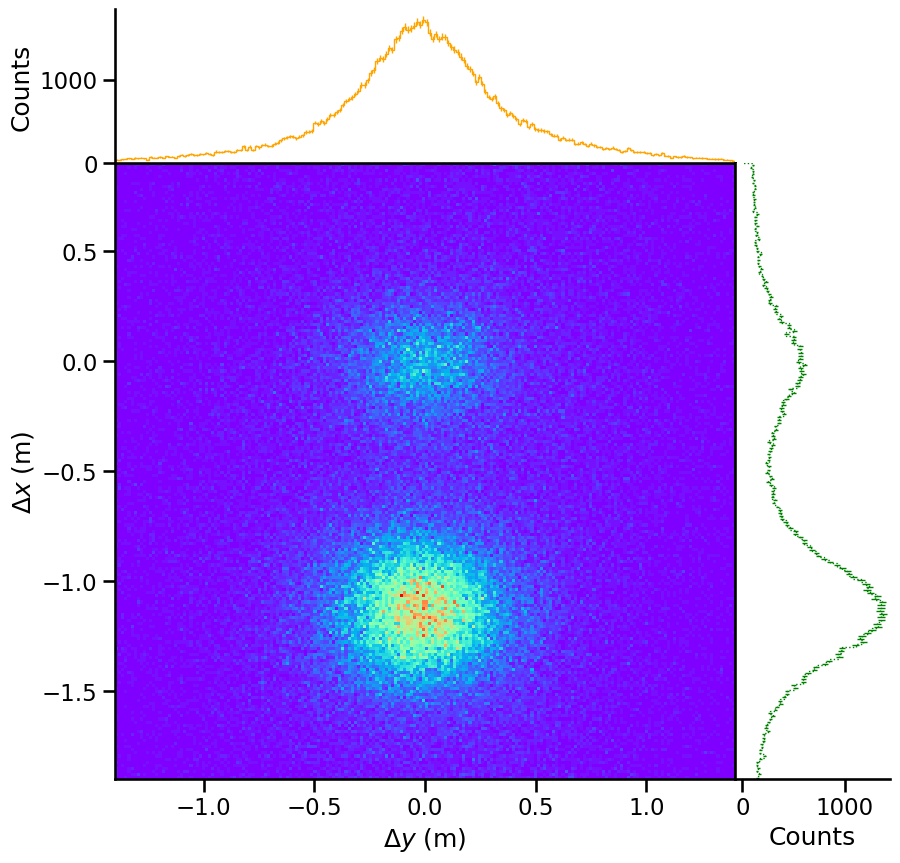

In [97]:
#fig, ax = plt.subplots()
#fig.set_size_inches(6, 6)
plt.figure(figsize=(10, 10))

h_dxdy = Hist(
                hist.axis.Regular(200, -1.4, 1.4, name="dy", label=r'$\Delta y$ (m)', flow=False),
                hist.axis.Regular(200, -1.9, 0.9, name="dx", label=r'$\Delta x$ (m)', flow=False),
            )
h_dxdy.fill(tdf['dy'][WCut],tdf['dx'][WCut])

h_dxdy.plot2d_full(
    main_cmap="rainbow",
    top_ls="-",
    top_color="orange",
    top_lw=1,
    side_ls=":",
    side_lw=1,
    side_color="green",
)

Drawing_uncolored_circle = plt.Circle( (0.6, 0.6 ),
                                      0.3 ,
                                      fill = False )
 
#axes.set_aspect( 1 )
#axes.add_artist( Drawing_uncolored_circle )

#h_dxdy.plot(ax=ax)
plt.show()

### Now it's time to create dx histograms for analysis

In [7]:
# Lets first define cuts and bin info to preserve consistancy bet. data and MC analysis
dxcuts = WCut & fCut
dxbins = [120, -3.5, 2.5]


In [8]:
# defining dx histograms with data
hdx_data = Hist(hist.axis.Regular(dxbins[0], dxbins[1], dxbins[2], name=r'$\Delta$x (m)'), storage=hist.storage.Double())
hdx_data.fill(tdf['dx'][dxcuts])
hdx_data_norm = hdx_data / hdx_data.sum()
# coin cut
hdx_data_coin = Hist(hist.axis.Regular(dxbins[0], dxbins[1], dxbins[2], name=r'$\Delta$x (m)'), storage=hist.storage.Double())
hdx_data_coin.fill(tdf['dx'][dxcuts & (abs(tdf['coinT_trig'] - 510.) < 20.)])
hdx_data_coin_norm = hdx_data_coin / hdx_data_coin.sum()
# dy cut
hdx_data_dy = Hist(hist.axis.Regular(dxbins[0], dxbins[1], dxbins[2], name=r'$\Delta$x (m)'), storage=hist.storage.Double())
hdx_data_dy.fill(tdf['dx'][dxcuts & (abs(tdf['dy']) < 0.3)])
hdx_data_dy_norm = hdx_data_dy / hdx_data_dy.sum()

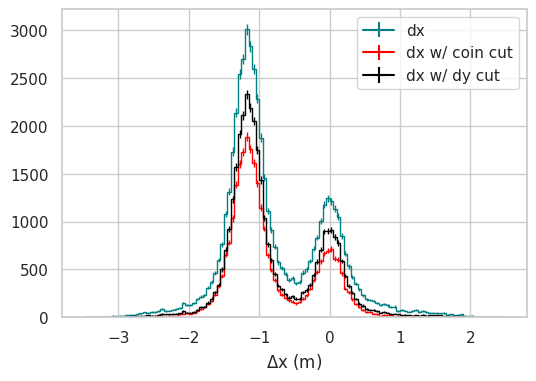

In [9]:
fig, ax = plt.subplots(figsize=(6,4))
#hdx_data_norm.plot(ax=ax, ls="-", color="teal", lw=1, label='dx')
#hdx_data_coin_norm.plot(ax=ax, ls="-", color="red", lw=1, label='dx w/ coin cut')
hdx_data.plot(ax=ax, ls="-", color="teal", lw=1, label='dx')
hdx_data_coin.plot(ax=ax, ls="-", color="red", lw=1, label='dx w/ coin cut')
hdx_data_dy.plot(ax=ax, ls="-", color="black", lw=1, label='dx w/ dy cut')
plt.legend()
plt.show()

## **** Simulation ****

In [10]:
# Reading the ROOT file
#fmc = uproot.open('/work/halla/sbs/pdbforce/gmn-ana/scripts/simulation/siout/qelas_ana_simu_sbs4_sbs50p_model2.root')
fmc = uproot.open('/lustre19/expphy/volatile/halla/sbs/pdbforce/gmn_ana/siout/qelas_ana_simu_sbs4_sbs50p_model2.root')
fmc.classnames()

{'Tout;2': 'TTree',
 'Tout;1': 'TTree',
 'c1;1': 'TCanvas',
 'c2;1': 'TCanvas',
 'c3;1': 'TCanvas',
 'h_W;1': 'TH1F',
 'h_W_cut;1': 'TH1F',
 'h_W_acut;1': 'TH1F',
 'h_dpel;1': 'TH1D',
 'h_Q2;1': 'TH1F',
 'h_dxHCAL;1': 'TH1F',
 'h_dyHCAL;1': 'TH1F',
 'h_dxHCAL_p;1': 'TH1F',
 'h_dxHCAL_n;1': 'TH1F',
 'h2_rcHCAL;1': 'TH2F',
 'h2_dxdyHCAL;1': 'TH2F',
 'h2_xyHCAL_p;1': 'TH2F',
 'h2_xyHCAL_n;1': 'TH2F'}

In [11]:
# Accessing the tree and reading it as pandas df
tmc = fmc['Tout']
tdfmc = tmc.arrays(library="pd")
tdfmc.columns
tdfmc.head()

,WCut,pCut,nCut,fiduCut,weight,mc_fnucl,ebeam,nu,Q2,W2,...,idblkHCAL,rblkHCAL,cblkHCAL,atimeHCAL,tdcHCAL,xHCAL_exp,yHCAL_exp,dx,dy,ToF_n
0,True,True,False,True,0.000719,1,3.7393,1.633245,3.138629,0.809909,...,103.0,8.0,6.0,34.978947,72.1,0.180509,0.104153,-1.186139,-0.026683,39.323107
1,True,False,False,True,0.000427,0,3.7393,1.609978,2.939786,0.965058,...,173.0,14.0,4.0,65.793651,96.9,-0.183167,0.075259,0.117846,-0.374407,39.431096
2,True,False,False,True,0.001143,1,3.7393,1.596643,2.759471,1.120333,...,21.0,1.0,8.0,31.615836,68.5,-0.510388,0.137250,-1.598040,0.304885,40.195142
3,False,False,False,False,0.001199,1,3.7393,1.753748,2.797391,1.377431,...,106.0,8.0,9.0,37.188922,72.7,-0.052957,0.623983,-0.936371,-0.091434,39.630399
4,True,False,False,True,0.000694,1,3.7393,1.603340,3.261415,0.630966,...,54.0,4.0,5.0,33.696558,69.8,0.139876,-0.124961,-1.799526,0.010349,40.007615


In [12]:
# Defining cut variables from tree to make my life easier
WCutmc = tdfmc['WCut']
fCutmc = tdfmc['fiduCut']
pCutmc = tdfmc['pCut']
nCutmc = tdfmc['nCut']

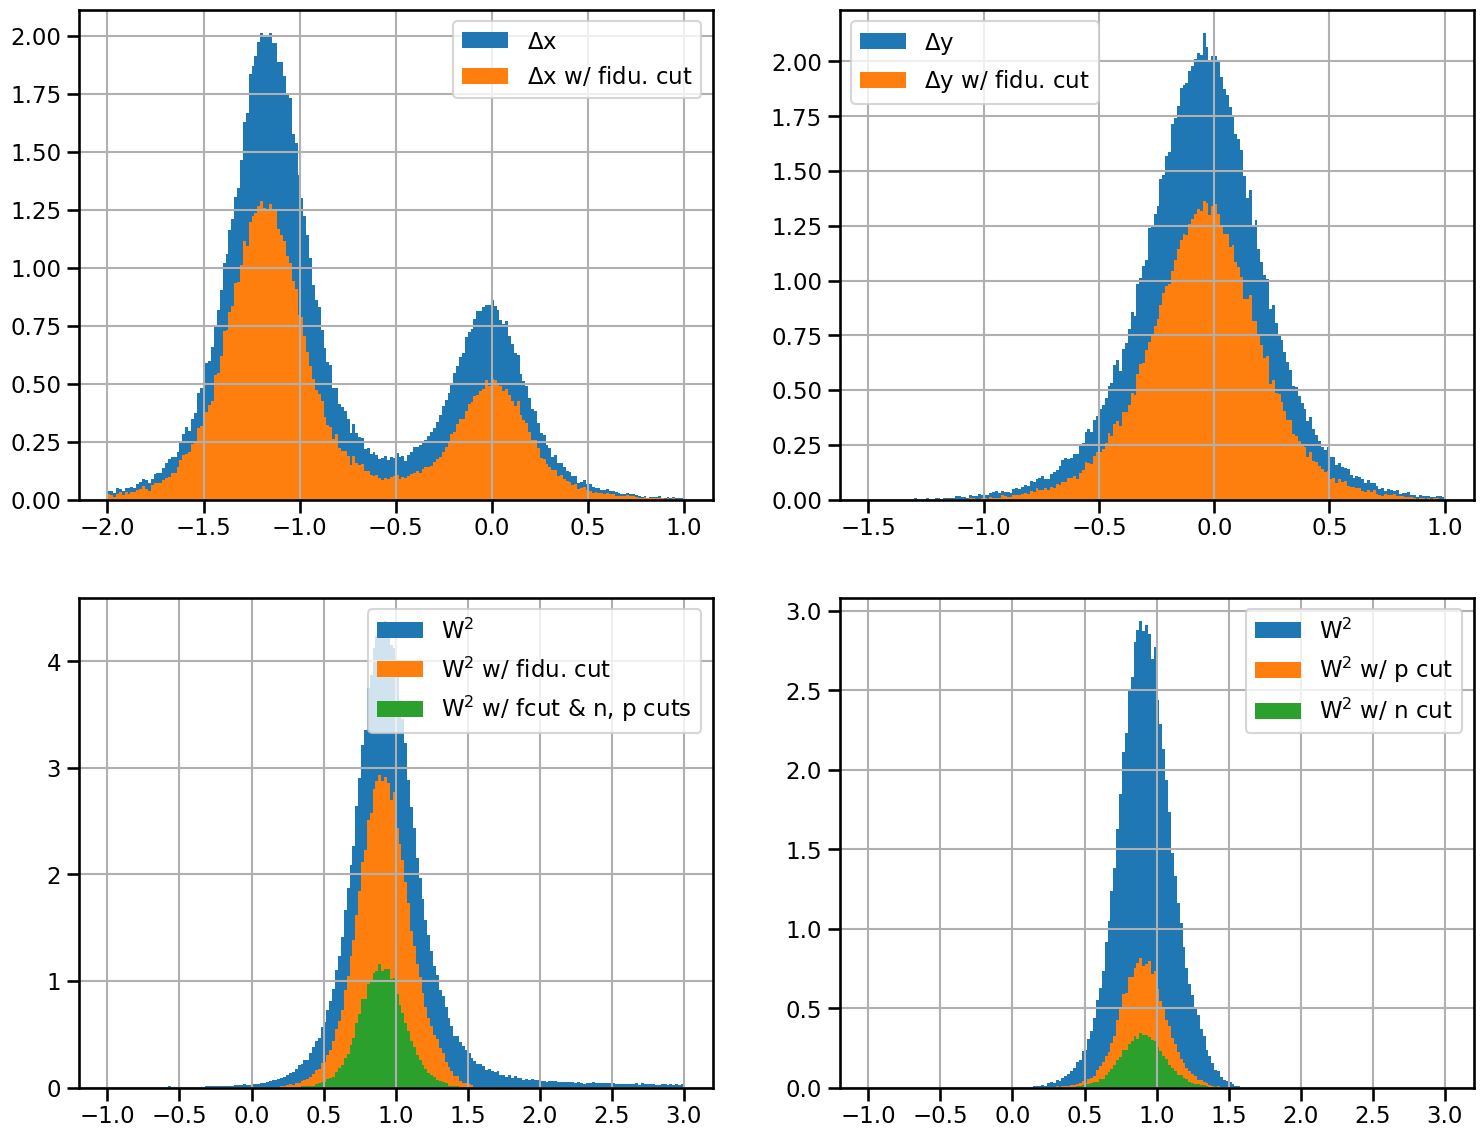

In [13]:
# Lets look at a few important histograms first
plt.style.use('default')
sns.set_context('talk')
fig, ax = plt.subplots(2, 2)
fig.set_size_inches(18, 14)
tdfmc['dx'][WCutmc].hist(bins=200, range=(-2, 1), weights=tdfmc['weight'][WCutmc], ax=ax[0, 0], label=r'$\Delta$x')
tdfmc['dx'][WCutmc & fCutmc].hist(bins=200, range=(-2, 1), weights=tdfmc['weight'][WCutmc & fCutmc], ax=ax[0, 0], label=r'$\Delta$x w/ fidu. cut')
tdfmc['dy'][WCutmc].hist(bins=200, range=(-1.5, 1), weights=tdfmc['weight'][WCutmc], ax=ax[0, 1], label=r'$\Delta$y')
tdfmc['dy'][WCutmc & fCutmc].hist(bins=200, range=(-1.5, 1), weights=tdfmc['weight'][WCutmc & fCutmc], ax=ax[0, 1], label=r'$\Delta$y w/ fidu. cut')
tdfmc['W2'].hist(bins=200, range=(-1, 3), weights=tdfmc['weight'], ax=ax[1, 0], label=r'W$^2$')
tdfmc['W2'][fCutmc].hist(bins=200, range=(-1, 3), weights=tdfmc['weight'][fCutmc], ax=ax[1, 0], label=r'W$^2$ w/ fidu. cut')
tdfmc['W2'][fCutmc & (nCutmc | pCutmc)].hist(bins=200, range=(-1, 3), weights=tdfmc['weight'][fCutmc & (nCutmc | pCutmc)], ax=ax[1, 0], label='W$^2$ w/ fcut & n, p cuts')
tdfmc['W2'][fCutmc].hist(bins=200, range=(-1, 3), weights=tdfmc['weight'][fCutmc], ax=ax[1, 1], label=r'W$^2$')
tdfmc['W2'][fCutmc & pCutmc].hist(bins=200, range=(-1, 3), weights=tdfmc['weight'][fCutmc & pCutmc], ax=ax[1, 1], label=r'W$^2$ w/ p cut')
tdfmc['W2'][fCutmc & nCutmc].hist(bins=200, range=(-1, 3), weights=tdfmc['weight'][fCutmc & nCutmc], ax=ax[1, 1], label=r'W$^2$ w/ n cut')
#tdfmc['ToF_n'][WCutmc].hist(bins=80, range=(38, 42), weights=tdfmc['weight'][WCutmc], ax=ax[1, 1], label='ToF (ns), no deflection')
for i in range(2):
    for j in range(2):
        ax[i, j].legend()

### Lets create dx histogram for MC

In [14]:
# Lets first define cuts and bin info to preserve consistancy bet. data and MC analysis
dxcutsmc = WCutmc & fCutmc & (abs(tdfmc['dy']) < 0.3)

In [15]:
# defining dx histograms with data
hdx_simu = Hist(hist.axis.Regular(dxbins[0], dxbins[1], dxbins[2], name=r'$\Delta$x (m)'), storage=hist.storage.Double())
hdx_simu.fill(tdfmc['dx'][dxcutsmc], weight=tdfmc['weight'][dxcutsmc])
hdx_simu_norm = hdx_simu / hdx_simu.sum()

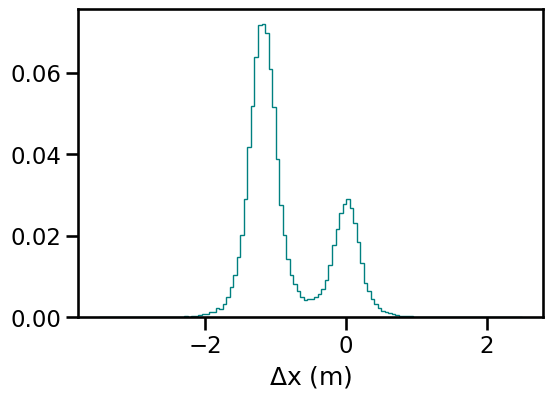

In [16]:
fig, ax = plt.subplots(figsize=(6,4))
x = hdx_simu_norm.plot(ax=ax, ls="-", color="teal", lw=1)
plt.show()

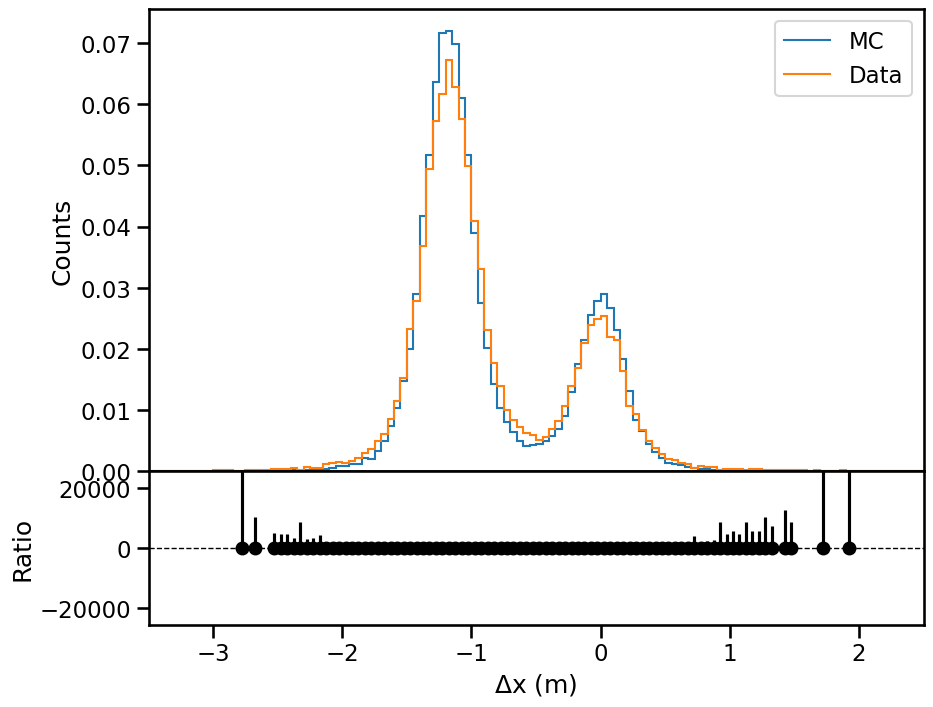

In [17]:
fig = plt.figure(figsize=(10, 8))
main_ax_artists, sublot_ax_arists = hdx_simu_norm.plot_ratio(
    #hdx_data_norm,
    hdx_data_coin_norm,
    #hdx_data_dy_norm,
    rp_ylabel=r"Ratio",
    rp_num_label="MC",
    rp_denom_label="Data",
    rp_uncert_draw_type="line",  # line or bar
)

### Lets investigate background shapes

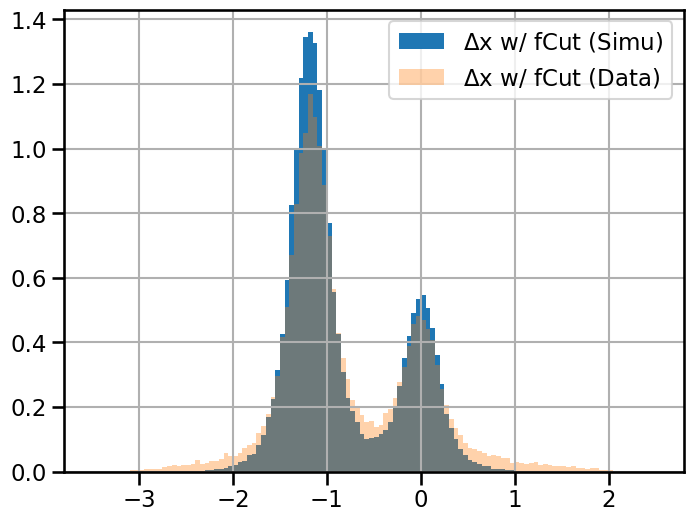

In [18]:
# Lets try to get the shape from data by putting different cuts
plt.style.use('default')
sns.set_context('talk')
fig, ax = plt.subplots()
fig.set_size_inches(8, 6)
bgCut = (tdf['W2'] > 2.5)
#hdx_data_norm.plot(ax=ax, ls="-", color="teal", lw=1)
tdfmc['dx'][WCutmc & fCutmc].hist(bins=dxbins[0], range=(dxbins[1], dxbins[2]), weights=tdfmc['weight'][WCutmc & fCutmc], ax=ax, label=r'$\Delta$x w/ fCut (Simu)', density=True)
tdf['dx'][WCut & fCut].hist(bins=dxbins[0], range=(dxbins[1], dxbins[2]), ax=ax, label=r'$\Delta$x w/ fCut (Data)', alpha=0.35, density=True)
#tdf['dx'][bgCut].hist(bins=dxbins[0], range=(dxbins[1], dxbins[2]), ax=ax, label=r'$\Delta$x', density=True, alpha=0.35)
#tdf['dx'][(tdf['dy'] > 0.9)].hist(bins=dxbins[0], range=(dxbins[1], dxbins[2]), ax=ax, label=r'$\Delta$x', alpha=0.35, density=True)
#tdf['dy'][WCut].hist(bins=200, range=(-1.5, 1), ax=ax, label=r'$\Delta$y')
#tdf['dy'][bgCut].hist(bins=200, range=(-1.5, 1), ax=ax, label=r'$\Delta$y')
plt.legend()
plt.show()

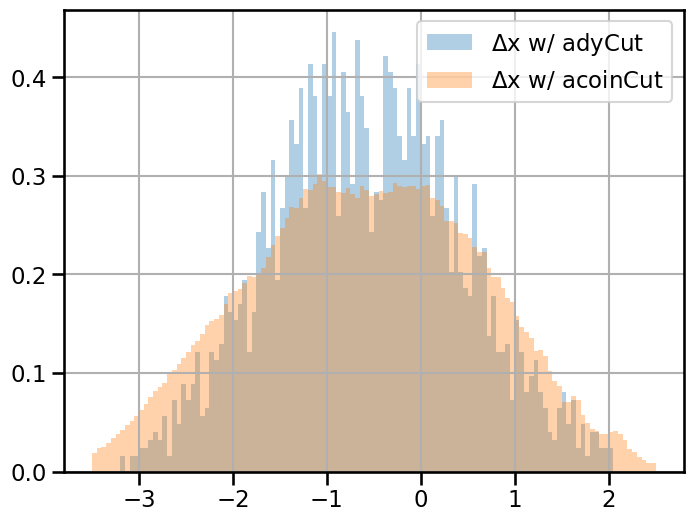

In [19]:
# Lets try to get the shape from data by putting different cuts
plt.style.use('default')
sns.set_context('talk')
fig, ax = plt.subplots()
fig.set_size_inches(8, 6)
aW2Cut = (tdf['W2'] < .2)
adyCut = tdf['dy'] > .6
acoinCut = (abs(tdf['coinT_trig'] - 510.) > 20.)
#hdx_data_norm.plot(ax=ax, ls="-", color="teal", lw=1)
#tdfmc['dx'][WCutmc & fCutmc].hist(bins=dxbins[0], range=(dxbins[1], dxbins[2]), weights=tdfmc['weight'][WCutmc & fCutmc], ax=ax, label=r'$\Delta$x w/ fidu. cut', density=True)
#tdf['dx'][WCut & fCut].hist(bins=dxbins[0], range=(dxbins[1], dxbins[2]), ax=ax, label=r'$\Delta$x w/ fidu. cut', alpha=0.35, density=True)
#tdf['dx'][aW2Cut & (tdf['dy'] > 0.9)].hist(bins=dxbins[0], range=(dxbins[1], dxbins[2]), ax=ax, label=r'$\Delta$x', density=True, alpha=0.35)
#tdf['dx'][(tdf['dy'] > 0.9)].hist(bins=dxbins[0], range=(dxbins[1], dxbins[2]), ax=ax, label=r'$\Delta$x', alpha=0.35, density=True)
tdf['dx'][adyCut & WCut & fCut].hist(bins=dxbins[0], range=(dxbins[1], dxbins[2]), ax=ax, density=True, alpha=0.35, label=r'$\Delta$x w/ adyCut')
tdf['dx'][acoinCut].hist(bins=dxbins[0], range=(dxbins[1], dxbins[2]), ax=ax, density=True, alpha=0.35, label=r'$\Delta$x w/ acoinCut')
#tdf['dy'][WCut].hist(bins=200, range=(-1.5, 1), ax=ax, label=r'$\Delta$y', density=True)
#tdf['dy'][aW2Cut].hist(bins=200, range=(-1.5, 1), ax=ax, label=r'$\Delta$y', alpha=.35, density=True)
plt.legend()
plt.show()

### Let's create W histograms for data and MC

In [20]:
# defining ranges for W histo
Wbins = [80, 0.2, 1.8]

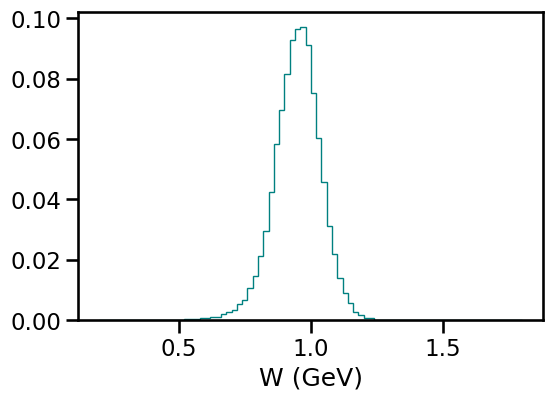

In [21]:
# defining dx histograms with data (MC)
hW_simu = Hist(hist.axis.Regular(Wbins[0], Wbins[1], Wbins[2], name=r'W (GeV)'), storage=hist.storage.Double())
hW_simu.fill(tdfmc['W'][fCutmc & (pCutmc | nCutmc)], weight=tdfmc['weight'][fCutmc & (pCutmc | nCutmc)])
hW_simu_norm = hW_simu / hW_simu.sum()
fig, ax = plt.subplots(figsize=(6,4))
hW_simu_norm.plot(ax=ax, ls="-", color="teal", lw=1)
plt.show()

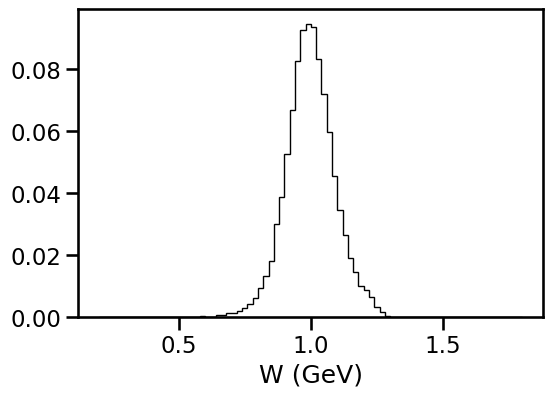

In [22]:
# defining dx histograms with data (Data)
hW_data = Hist(hist.axis.Regular(Wbins[0], Wbins[1], Wbins[2], name=r'W (GeV)'), storage=hist.storage.Double())
hW_data.fill(tdf['W'][fCut & (pCut | nCut)])
hW_data_norm = hW_data / hW_data.sum()
fig, ax = plt.subplots(figsize=(6,4))
hW_data_norm.plot(ax=ax, ls="-", color="black", lw=1)
plt.show()

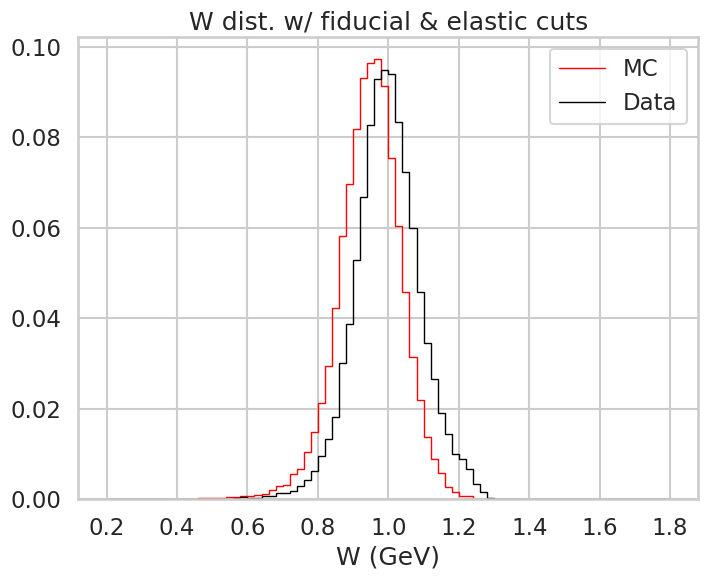

In [23]:
sns.set_style('whitegrid')
sns.set_context('talk')
fig, ax = plt.subplots()
fig.set_size_inches(8, 6)
hW_simu_norm.plot(ax=ax, ls="-", color="red", lw=1, label='MC')
hW_data_norm.plot(ax=ax, ls="-", color="black", lw=1, label='Data')
ax.set_title('W dist. w/ fiducial & elastic cuts')
plt.legend()
plt.show()

## Variying W cut
The idea is to see how the fit parameters R & B changes with the range of W cut. In order to vary the W cut in a systematic way I have formulated the cut in the following way:
$$|W - W_{mean}| \le W_{width}$$
and then varied the width over a range of 0.15 GeV to 0.35 GeV keeping the mean constant.

#### Findings
1. R seems to stay stable with varying W cut
2. B changes significantly to keep R stable
3. $\chi^{2}$ follows the same trend as B the reason behind which is not totally clear. The thing to keep in mind is that the number of bins doesn't change so with varying W cut we essentially vary the number of counts per bin.

#### Inference
1. The fact that R stays more or less the same with varying W cut says that our estimation of background is reasonable because no matter how much background you let in the ration of signal doesn't change.
2. Standard deviation of the R values should give us the systematic uncertainty! :) 

In [24]:
#sysstd_W_df = pd.DataFrame(pd.read_csv('../simulation/siout/sysstudy/sbs4_sbs50_sys_study.csv'))
sysstd_W_df_polbg = pd.DataFrame(pd.read_csv('../sbs4-sbs50p/poly3_sbs4_sbs50p_sys_study.csv'))
sysstd_W_df = pd.DataFrame(pd.read_csv('../sbs4-sbs50p/databg_sbs4_sbs50p_sys_study.csv'))
sysstd_W_df.head()

,Wmean,Wwidth,R,B,chi2
0,0.91,0.15,0.9468,0.1429,1.39
1,0.91,0.18,0.9546,0.1774,1.53
2,0.91,0.19,0.9559,0.1892,1.66
3,0.91,0.20,0.9503,0.2037,1.62
4,0.91,0.21,0.9493,0.2171,1.70


In [25]:
xlabels = ['|W - 0.91| <= {}'.format(val) for val in sysstd_W_df['Wwidth']]
#print(xlabels)

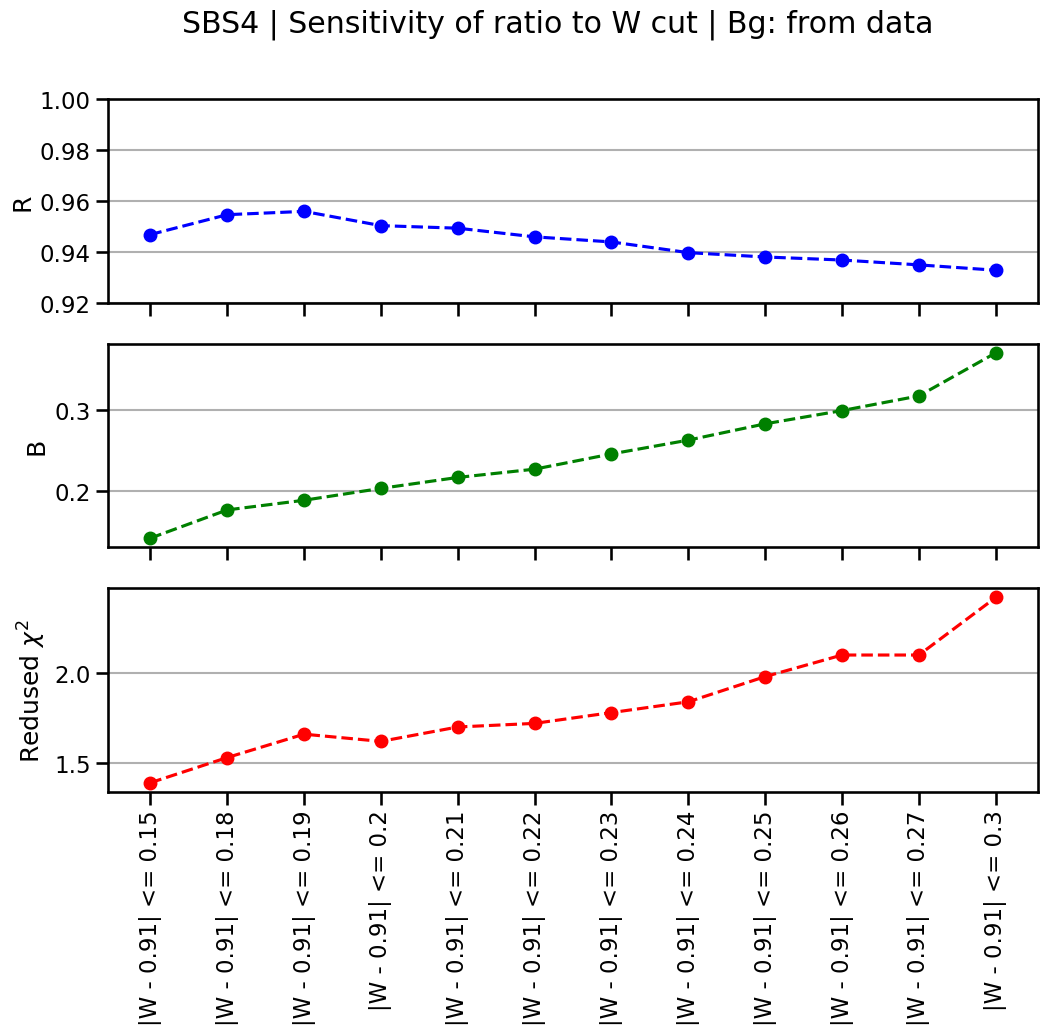

In [26]:
# plotting various parameters vs cut width
plt.style.use('default')
sns.set_context('talk')
fig, ax = plt.subplots(3, 1, sharex=True)
fig.set_size_inches(12, 9)

ax[0].plot(xlabels, sysstd_W_df['R'], marker='o', linestyle='--', color='b')
ax[1].plot(xlabels, sysstd_W_df['B'], marker='o', linestyle='--', color='g')
ax[2].plot(xlabels, sysstd_W_df['chi2'], marker='o', linestyle='--', color='r')

ax[0].set_ylim(0.92,1)
ax[0].set_ylabel('R')
ax[0].grid(axis = "y")
ax[1].set_ylabel('B')
ax[1].grid(axis = "y")
ax[2].set_ylabel(r'Redused $\chi^{2}$')
ax[2].grid(axis = "y")

fig.suptitle("SBS4 | Sensitivity of ratio to W cut | Bg: from data")

plt.xticks(rotation=90)
plt.show()

#.91,.35,.9289,.4208,2.88

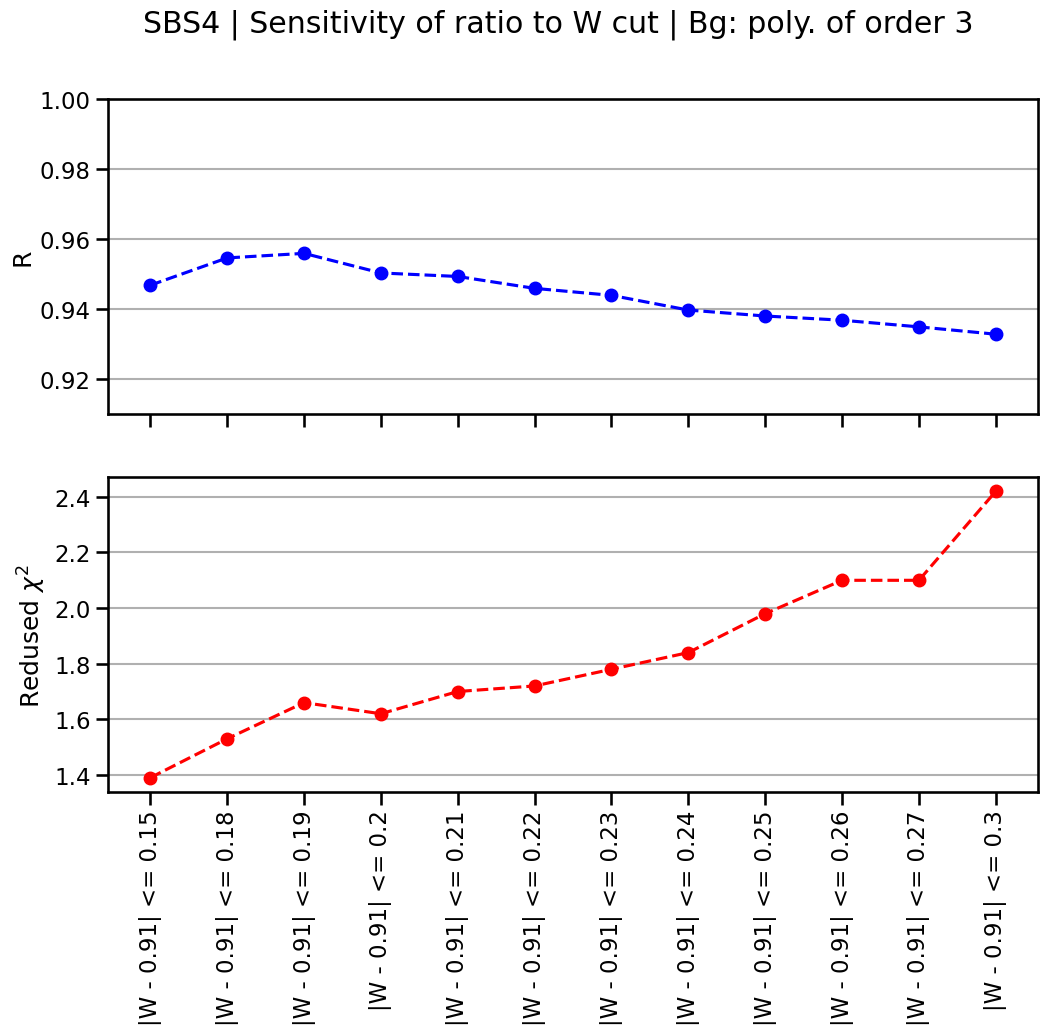

In [27]:
# plotting various parameters vs cut width
plt.style.use('default')
sns.set_context('talk')
fig, ax = plt.subplots(2, 1, sharex=True)
fig.set_size_inches(12, 9)

ax[0].plot(xlabels, sysstd_W_df['R'], marker='o', linestyle='--', color='b')
#ax[1].plot(xlabels, sysstd_W_df['B'], marker='o', linestyle='--', color='g')
ax[1].plot(xlabels, sysstd_W_df['chi2'], marker='o', linestyle='--', color='r')

ax[0].set_ylim(0.91,1)
ax[0].set_ylabel('R')
ax[0].grid(axis = "y")

ax[1].set_ylabel('B')
ax[1].set_ylabel(r'Redused $\chi^{2}$')
ax[1].grid(axis = "y")

fig.suptitle("SBS4 | Sensitivity of ratio to W cut | Bg: poly. of order 3")

plt.xticks(rotation=90)
plt.show()

#.91,.35,.9297,0,1.74

## Studying R by scanning W2 cut

In [28]:
df_wcut_scan = pd.read_csv("varyR_vs_W2.csv")
df_wcut_scan.head()

,wmin,wmax,R0,R0err,R1,R1err,R2,R2err,R3,R3err
0,0.6,0.7,1.303440,0.167487,1.402240,0.186943,1.365360,0.196447,1.326590,0.210537
1,0.7,0.8,0.983050,0.055782,0.968223,0.060225,0.976881,0.060092,0.992772,0.060697
2,0.8,0.9,0.980784,0.025768,0.980148,0.027567,0.982634,0.027314,0.983770,0.027814
3,0.9,1.0,0.955947,0.018213,0.934169,0.019293,0.935413,0.019224,0.936723,0.019440
4,1.0,1.1,1.065780,0.025746,0.993077,0.030409,1.008890,0.029976,0.997566,0.030766


In [29]:
## *********
# Scan with 0.1 GeV interval
df_wcut_scan_v1 = df_wcut_scan.iloc[:6,:]

In [30]:
# xlabels
xlab = ['{} < W <= {}'.format(row['wmin'],row['wmax']) for index, row in df_wcut_scan_v1.iterrows()]

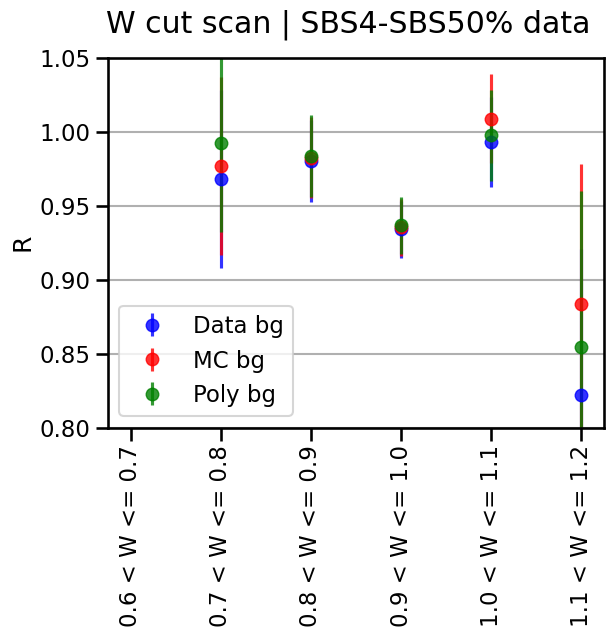

In [31]:
# plotting various parameters vs cut width
plt.style.use('default')
sns.set_context('talk')
fig, ax = plt.subplots()
#fig.set_size_inches(12, 9)

#ax.plot(xlab, df_wcut_scan['R1'], marker='o', linestyle='--', color='b')
ax.errorbar(xlab, df_wcut_scan_v1['R1'], yerr=df_wcut_scan_v1['R1err'], marker='o', linestyle='', color='b', alpha=0.8, label='Data bg')
ax.errorbar(xlab, df_wcut_scan_v1['R2'], yerr=df_wcut_scan_v1['R2err'], marker='o', linestyle='', color='r', alpha=0.8, label='MC bg')
ax.errorbar(xlab, df_wcut_scan_v1['R3'], yerr=df_wcut_scan_v1['R3err'], marker='o', linestyle='', color='g', alpha=0.8, label='Poly bg')

ax.set_ylim(0.8,1.05)
ax.set_ylabel('R')
ax.grid(axis = "y")
#ax.set_title('W cut scan (w/ fidu. cut) | SBS4-SBS50% data')

fig.suptitle('W cut scan | SBS4-SBS50% data')

plt.xticks(rotation=90)
plt.legend()
plt.show()

In [32]:
## *********
# Scan with 0.2 GeV interval
df_wcut_scan_v2 = df_wcut_scan.iloc[6:9,:]

In [33]:
df_wcut_scan_v2

,wmin,wmax,R0,R0err,R1,R1err,R2,R2err,R3,R3err
6,0.65,0.85,0.985033,0.033307,0.984675,0.036135,0.991468,0.035265,0.983054,0.036348
7,0.85,1.05,0.982484,0.014148,0.953136,0.015300,0.955953,0.015197,0.960363,0.015382
8,1.05,1.25,1.152290,0.033069,0.947664,0.052336,0.999234,0.050389,0.965175,0.055008


In [34]:
# xlabels
xlab_v2 = ['{} < W <= {}'.format(row['wmin'],row['wmax']) for index, row in df_wcut_scan_v2.iterrows()]

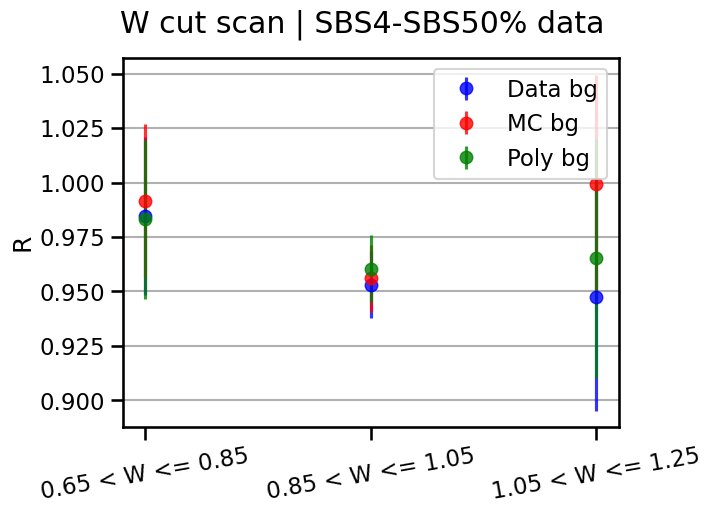

In [35]:
# plotting various parameters vs cut width
plt.style.use('default')
sns.set_context('talk')
fig, ax = plt.subplots()
#fig.set_size_inches(12, 9)

#ax.plot(xlab, df_wcut_scan['R1'], marker='o', linestyle='--', color='b')
ax.errorbar(xlab_v2, df_wcut_scan_v2['R1'], yerr=df_wcut_scan_v2['R1err'], marker='o', linestyle='', color='b', alpha=0.8, label='Data bg')
ax.errorbar(xlab_v2, df_wcut_scan_v2['R2'], yerr=df_wcut_scan_v2['R2err'], marker='o', linestyle='', color='r', alpha=0.8, label='MC bg')
ax.errorbar(xlab_v2, df_wcut_scan_v2['R3'], yerr=df_wcut_scan_v2['R3err'], marker='o', linestyle='', color='g', alpha=0.8, label='Poly bg')

#ax.set_ylim(0.8,1.05)
ax.set_ylabel('R')
ax.grid(axis = "y")
#ax.set_title('W cut scan (w/ fidu. cut) | SBS4-SBS50% data')

fig.suptitle('W cut scan | SBS4-SBS50% data')

plt.xticks(rotation=10)
plt.legend()
plt.show()

In [36]:
## *********
# Scan around 0.9 GeV with 0.05 GeV
df_wcut_scan_v3 = df_wcut_scan.iloc[9:,:]

In [37]:
df_wcut_scan_v3

,wmin,wmax,R0,R0err,R1,R1err,R2,R2err,R3,R3err
9,0.80,1.00,0.963344,0.014783,0.943485,0.015745,0.945156,0.015709,0.948648,0.016073
10,0.75,1.05,0.979033,0.013107,0.951725,0.014145,0.954791,0.014091,0.958404,0.014305
11,0.70,1.10,0.994277,0.012474,0.956361,0.013735,0.962006,0.013652,0.964468,0.013869
12,0.65,1.15,0.997801,0.012124,0.949003,0.013703,0.955982,0.013552,0.958093,0.013964
13,0.60,1.20,1.006440,0.012033,0.951952,0.013845,0.960302,0.013681,0.962530,0.014009
14,0.55,1.25,1.010450,0.012025,0.954608,0.013858,0.963135,0.013746,0.965246,0.014115


In [38]:
# xlabels
xlab_v3 = ['{} < W <= {}'.format(row['wmin'],row['wmax']) for index, row in df_wcut_scan_v3.iterrows()]

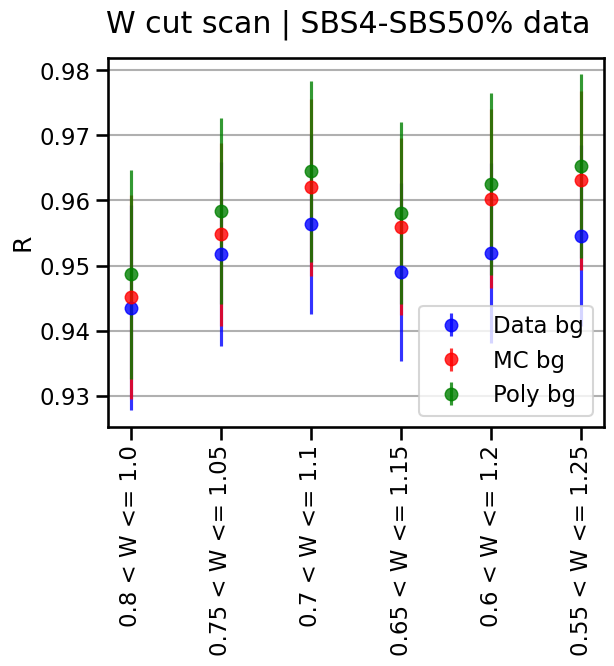

In [39]:
# plotting various parameters vs cut width
plt.style.use('default')
sns.set_context('talk')
fig, ax = plt.subplots()
#fig.set_size_inches(12, 9)

#ax.plot(xlab, df_wcut_scan['R1'], marker='o', linestyle='--', color='b')
ax.errorbar(xlab_v3, df_wcut_scan_v3['R1'], yerr=df_wcut_scan_v3['R1err'], marker='o', linestyle='', color='b', alpha=0.8, label='Data bg')
ax.errorbar(xlab_v3, df_wcut_scan_v3['R2'], yerr=df_wcut_scan_v3['R2err'], marker='o', linestyle='', color='r', alpha=0.8, label='MC bg')
ax.errorbar(xlab_v3, df_wcut_scan_v3['R3'], yerr=df_wcut_scan_v3['R3err'], marker='o', linestyle='', color='g', alpha=0.8, label='Poly bg')

#ax.set_ylim(0.8,1.05)
ax.set_ylabel('R')
ax.grid(axis = "y")
#ax.set_title('W cut scan (w/ fidu. cut) | SBS4-SBS50% data')

fig.suptitle('W cut scan | SBS4-SBS50% data')

plt.xticks(rotation=90)
plt.legend()
plt.show()

## Studying R by scanning HCAL energy

In [40]:
df_ehcal_scan = pd.read_csv("varyR_vs_eHCAL.csv")
df_ehcal_scan.head()

,eHCALmin,R0,R0err,R1,R1err,R2,R2err,R3,R3err
0,0.000,1.004370,0.012076,0.948068,0.013834,0.956555,0.013727,0.959502,0.014146
1,0.025,0.992612,0.012136,0.928005,0.013272,0.933059,0.013146,0.942823,0.013488
2,0.050,0.978649,0.012332,0.926948,0.013190,0.930751,0.013122,0.937593,0.013508
3,0.075,0.952718,0.012602,0.911800,0.013297,0.913969,0.013241,0.916608,0.013710
4,0.100,0.923578,0.013005,0.890306,0.013661,0.892953,0.013600,0.891691,0.014309


In [41]:
# xlabels
xlab_ehcal = ['eHCAL > {}'.format(row['eHCALmin']) for index, row in df_ehcal_scan.iterrows()]

In [42]:
xlab_ehcal

['eHCAL > 0.0',
 'eHCAL > 0.025',
 'eHCAL > 0.05',
 'eHCAL > 0.075',
 'eHCAL > 0.1',
 'eHCAL > 0.125']

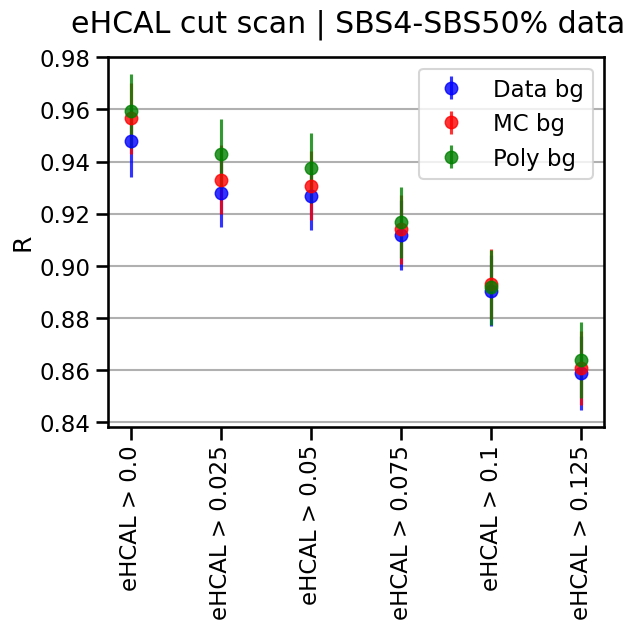

In [43]:
# plotting various parameters vs cut width
plt.style.use('default')
sns.set_context('talk')
fig, ax = plt.subplots()
#fig.set_size_inches(12, 9)

#ax.plot(xlab, df_wcut_scan['R1'], marker='o', linestyle='--', color='b')
ax.errorbar(xlab_ehcal, df_ehcal_scan['R1'], yerr=df_ehcal_scan['R1err'], marker='o', linestyle='', color='b', alpha=0.8, label='Data bg')
ax.errorbar(xlab_ehcal, df_ehcal_scan['R2'], yerr=df_ehcal_scan['R2err'], marker='o', linestyle='', color='r', alpha=0.8, label='MC bg')
ax.errorbar(xlab_ehcal, df_ehcal_scan['R3'], yerr=df_ehcal_scan['R3err'], marker='o', linestyle='', color='g', alpha=0.8, label='Poly bg')

#ax.set_ylim(0.8,1.05)
ax.set_ylabel('R')
ax.grid(axis = "y")
#ax.set_title('W cut scan (w/ fidu. cut) | SBS4-SBS50% data')

fig.suptitle('eHCAL cut scan | SBS4-SBS50% data')

plt.xticks(rotation=90)
plt.legend()
plt.show()

## Studying R by varying HCAL-SH ADC coincidence time

In [44]:
df_coint_scan = pd.read_csv("varyR_vs_coinT.csv")
df_coint_scan.head()

,low,hi,R0,R0err,R1,R1err,R2,R2err,R3,R3err
0,-1.4,1.6,0.781599,0.012275,0.785782,0.012480,0.785908,0.012409,0.781721,0.012579
1,-2.9,3.1,0.924697,0.011860,0.912074,0.012246,0.913566,0.012120,0.903190,0.012376
2,-4.4,4.6,0.987401,0.012121,0.960027,0.012581,0.961729,0.012538,0.953281,0.012832
3,-5.9,6.1,0.995345,0.012093,0.957454,0.012668,0.959621,0.012615,0.955093,0.013001
4,-7.4,7.6,0.997395,0.012061,0.951862,0.012760,0.954316,0.012659,0.955603,0.012930


In [45]:
# xlabels
xlab_coint = ['{} < coinTime < {}'.format(row['low'],row['hi']) for index, row in df_coint_scan.iterrows()]

In [46]:
xlab_coint

['-1.4 < coinTime < 1.6',
 '-2.9 < coinTime < 3.1',
 '-4.4 < coinTime < 4.6',
 '-5.9 < coinTime < 6.1',
 '-7.4 < coinTime < 7.6',
 '-8.9 < coinTime < 9.1']

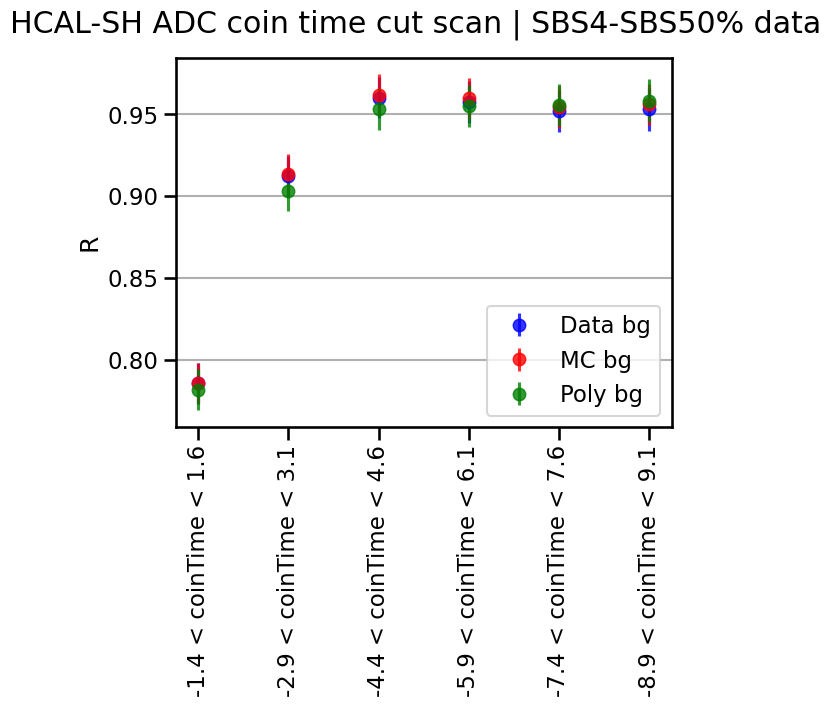

In [47]:
# plotting various parameters vs cut width
plt.style.use('default')
sns.set_context('talk')
fig, ax = plt.subplots()
#fig.set_size_inches(12, 9)

#ax.plot(xlab, df_wcut_scan['R1'], marker='o', linestyle='--', color='b')
ax.errorbar(xlab_coint, df_coint_scan['R1'], yerr=df_coint_scan['R1err'], marker='o', linestyle='', color='b', alpha=0.8, label='Data bg')
ax.errorbar(xlab_coint, df_coint_scan['R2'], yerr=df_coint_scan['R2err'], marker='o', linestyle='', color='r', alpha=0.8, label='MC bg')
ax.errorbar(xlab_coint, df_coint_scan['R3'], yerr=df_coint_scan['R3err'], marker='o', linestyle='', color='g', alpha=0.8, label='Poly bg')

#ax.set_ylim(0.94,1.05)
ax.set_ylabel('R')
ax.grid(axis = "y")
#ax.set_title('W cut scan (w/ fidu. cut) | SBS4-SBS50% data')

fig.suptitle('HCAL-SH ADC coin time cut scan | SBS4-SBS50% data')

plt.xticks(rotation=90)
plt.legend()
plt.show()

## Studying R by varying PS energy

In [48]:
df_eps_scan = pd.read_csv("varyR_vs_ePS.csv")
df_eps_scan.head()

,epsmin,R0,R0err,R1,R1err,R2,R2err,R3,R3err
0,0.2,1.004370,0.012076,0.948068,0.013834,0.956555,0.013727,0.959502,0.014146
1,0.3,1.001460,0.012194,0.945597,0.013986,0.954383,0.013870,0.957467,0.014206
2,0.4,0.997184,0.012430,0.938554,0.014250,0.947291,0.014132,0.949396,0.014487
3,0.5,1.000550,0.012994,0.939613,0.014965,0.948937,0.014775,0.951329,0.015098
4,0.6,0.993523,0.013753,0.932557,0.015777,0.942698,0.015626,0.942366,0.015977


In [49]:
# xlabels
xlab_eps = ['ePS > {}'.format(row['epsmin']) for index, row in df_eps_scan.iterrows()]
xlab_eps

['ePS > 0.2', 'ePS > 0.3', 'ePS > 0.4', 'ePS > 0.5', 'ePS > 0.6', 'ePS > 0.7']

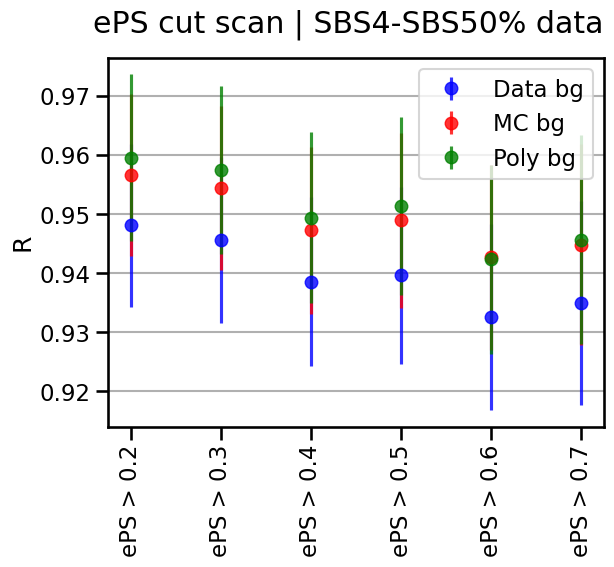

In [50]:
# plotting various parameters vs cut width
plt.style.use('default')
sns.set_context('talk')
fig, ax = plt.subplots()
#fig.set_size_inches(12, 9)

#ax.plot(xlab, df_wcut_scan['R1'], marker='o', linestyle='--', color='b')
ax.errorbar(xlab_eps, df_eps_scan['R1'], yerr=df_eps_scan['R1err'], marker='o', linestyle='', color='b', alpha=0.8, label='Data bg')
ax.errorbar(xlab_eps, df_eps_scan['R2'], yerr=df_eps_scan['R2err'], marker='o', linestyle='', color='r', alpha=0.8, label='MC bg')
ax.errorbar(xlab_eps, df_eps_scan['R3'], yerr=df_eps_scan['R3err'], marker='o', linestyle='', color='g', alpha=0.8, label='Poly bg')

#ax.set_ylim(0.8,1.05)
ax.set_ylabel('R')
ax.grid(axis = "y")
#ax.set_title('W cut scan (w/ fidu. cut) | SBS4-SBS50% data')

fig.suptitle('ePS cut scan | SBS4-SBS50% data')

plt.xticks(rotation=90)
plt.legend()
plt.show()